In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
!unzip /content/drive/MyDrive/MMOTU.zip -d /content/drive/MyDrive/MMOTU


Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/147.PNG  
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/147_binary.PNG  
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/147_binary_binary.PNG  
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/148.PNG  
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/148_binary.PNG  
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/148_binary_binary.PNG  
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/149.PNG  
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/149_binary.PNG  
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/149_binary_binary.PNG  
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/14_binary.PNG  
  inflating: /content/drive/MyDrive/MMOTU/MMOTU/OTU_2d/annotations/14_binary_binary.PNG  
  inflating: /conten

In [5]:
!ls /content/drive/MyDrive/MMOTU


MMOTU


In [9]:
import os, shutil

BASE_PATH = "/content/drive/MyDrive/MMOTU/MMOTU/OTU_2d"
IMG_PATH = os.path.join(BASE_PATH, "images")
ANN_PATH = os.path.join(BASE_PATH, "annotations")

OUT_PATH = "/content/drive/MyDrive/MMOTU_splits_full"

splits = ["train", "val", "test"]


In [19]:
import os
import shutil
from collections import defaultdict, Counter
from sklearn.model_selection import train_test_split
from tqdm import tqdm


In [23]:
# Original dataset paths
BASE_DATASET = "/content/drive/MyDrive/MMOTU/MMOTU/OTU_2d"
IMAGE_DIR = os.path.join(BASE_DATASET, "images")
TRAIN_CLS = os.path.join(BASE_DATASET, "train_cls.txt")
VAL_CLS = os.path.join(BASE_DATASET, "val_cls.txt")

# Final dataset path
OUTPUT_ROOT = "/content/MMOTU_splits_full"

In [25]:
# Original class IDs → Clinical labels
CLASS_MAP = {
    0: "Normal_Ovary",
    1: "Simple_Cyst",
    2: "Teratoma",
    3: "Serous_Cystadenoma",
    4: "Mucinous_Cystadenoma",
    5: "Chocolate_Cyst",
    6: "Theca_Cell_Tumor"
    # class 7 (High Grade Serous) is intentionally removed
}


In [39]:
def read_labels(label_file):
    data = []
    with open(label_file, "r") as f:
        for line in f:
            img, cls = line.strip().split()
            cls = int(cls)
            if cls in CLASS_MAP:  # removes class 7 automatically
                data.append((img, cls))
    return data

train_data = read_labels(TRAIN_CLS)
val_data = read_labels(VAL_CLS)

all_data = train_data + val_data

In [28]:
class_counts = Counter([cls for _, cls in all_data])
print("Class distribution after removal:")
for cls, count in class_counts.items():
    print(CLASS_MAP[cls], ":", count)


Class distribution after removal:
Chocolate_Cyst : 267
Serous_Cystadenoma : 88
Simple_Cyst : 219
Theca_Cell_Tumor : 104
Teratoma : 336
Normal_Ovary : 336
Mucinous_Cystadenoma : 66


In [29]:
class_images = defaultdict(list)

for img_name, cls in all_data:
    img_path = os.path.join(IMAGE_DIR, img_name)
    if os.path.exists(img_path):
        class_images[CLASS_MAP[cls]].append(img_path)


In [30]:
for split in ["train", "val", "test"]:
    for cls_name in CLASS_MAP.values():
        os.makedirs(os.path.join(OUTPUT_ROOT, split, cls_name), exist_ok=True)


In [31]:
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1


In [32]:
for cls_name, images in class_images.items():
    train_imgs, temp_imgs = train_test_split(
        images, test_size=(1 - train_ratio), random_state=42
    )

    val_imgs, test_imgs = train_test_split(
        temp_imgs,
        test_size=test_ratio / (test_ratio + val_ratio),
        random_state=42
    )

    for img in train_imgs:
        shutil.copy(img, os.path.join(OUTPUT_ROOT, "train", cls_name))

    for img in val_imgs:
        shutil.copy(img, os.path.join(OUTPUT_ROOT, "val", cls_name))

    for img in test_imgs:
        shutil.copy(img, os.path.join(OUTPUT_ROOT, "test", cls_name))


In [33]:
print("\nFinal dataset verification:\n")

for split in ["train", "val", "test"]:
    total = 0
    print(f"{split.upper()}:")
    for cls_name in CLASS_MAP.values():
        count = len(os.listdir(os.path.join(OUTPUT_ROOT, split, cls_name)))
        total += count
        print(f"  {cls_name}: {count}")
    print(f"  Total images: {total}\n")



Final dataset verification:

TRAIN:
  Normal_Ovary: 235
  Simple_Cyst: 153
  Teratoma: 235
  Serous_Cystadenoma: 61
  Mucinous_Cystadenoma: 46
  Chocolate_Cyst: 186
  Theca_Cell_Tumor: 72
  Total images: 988

VAL:
  Normal_Ovary: 67
  Simple_Cyst: 44
  Teratoma: 67
  Serous_Cystadenoma: 18
  Mucinous_Cystadenoma: 13
  Chocolate_Cyst: 54
  Theca_Cell_Tumor: 21
  Total images: 284

TEST:
  Normal_Ovary: 34
  Simple_Cyst: 22
  Teratoma: 34
  Serous_Cystadenoma: 9
  Mucinous_Cystadenoma: 7
  Chocolate_Cyst: 27
  Theca_Cell_Tumor: 11
  Total images: 144



In [34]:
print("Preprocessing completed successfully!")
print("Final dataset ready for YOLO classification training.")


Preprocessing completed successfully!
Final dataset ready for YOLO classification training.


In [36]:
YOLO_AUGMENTATIONS = {
    "hsv_h": 0.015,
    "hsv_s": 0.7,
    "hsv_v": 0.4,
    "degrees": 10,
    "translate": 0.1,
    "scale": 0.5,
    "fliplr": 0.5,
    "flipud": 0.0,
    "erasing": 0.4,
    "auto_augment": "randaugment"
}


In [42]:
!pip install -U ultralytics


In [54]:
import os

model = YOLO("runs/classify/train/weights/best.pt")

test_image_paths = []
test_root = os.path.join(DATA_PATH, "test") # Use DATA_PATH for consistency

# Assuming CLASS_MAP is available from previous cells
# If not, it would need to be re-imported or defined here.
# For this context, it is available in the kernel state.
for cls_name in CLASS_MAP.values(): # Iterate through each class subdirectory
    cls_path = os.path.join(test_root, cls_name)
    if os.path.exists(cls_path):
        for img_file in os.listdir(cls_path):
            # Filter for common image file extensions
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')):
                test_image_paths.append(os.path.join(cls_path, img_file))

# Perform prediction on the collected list of image paths
results = model.predict(
    source=test_image_paths,
    imgsz=224
)


0: 224x224 Normal_Ovary 0.99, Serous_Cystadenoma 0.01, Simple_Cyst 0.00, Teratoma 0.00, Chocolate_Cyst 0.00, 24.5ms
1: 224x224 Normal_Ovary 0.99, Simple_Cyst 0.00, Theca_Cell_Tumor 0.00, Teratoma 0.00, Chocolate_Cyst 0.00, 24.5ms
2: 224x224 Normal_Ovary 0.98, Serous_Cystadenoma 0.01, Teratoma 0.00, Chocolate_Cyst 0.00, Theca_Cell_Tumor 0.00, 24.5ms
3: 224x224 Normal_Ovary 0.97, Theca_Cell_Tumor 0.01, Chocolate_Cyst 0.01, Serous_Cystadenoma 0.01, Teratoma 0.00, 24.5ms
4: 224x224 Normal_Ovary 0.36, Chocolate_Cyst 0.21, Simple_Cyst 0.15, Serous_Cystadenoma 0.12, Mucinous_Cystadenoma 0.08, 24.5ms
5: 224x224 Normal_Ovary 0.97, Teratoma 0.02, Theca_Cell_Tumor 0.01, Mucinous_Cystadenoma 0.00, Simple_Cyst 0.00, 24.5ms
6: 224x224 Normal_Ovary 0.93, Chocolate_Cyst 0.03, Mucinous_Cystadenoma 0.01, Serous_Cystadenoma 0.01, Simple_Cyst 0.01, 24.5ms
7: 224x224 Normal_Ovary 1.00, Teratoma 0.00, Theca_Cell_Tumor 0.00, Simple_Cyst 0.00, Serous_Cystadenoma 0.00, 24.5ms
8: 224x224 Chocolate_Cyst 0.79, M

In [55]:
import pandas as pd

results_path = "runs/classify/train/results.csv"
df = pd.read_csv(results_path)

# Show all available columns
print(df.columns)


Index(['epoch', 'time', 'train/loss', 'metrics/accuracy_top1',
       'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2'],
      dtype='object')


In [67]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
!cp -r /content/runs /content/drive/MyDrive/


In [77]:
!mkdir -p /content/drive/MyDrive/YOLO_MMOTU_RESULTS
!mv /content/drive/MyDrive/runs/classify/train \
    /content/drive/MyDrive/YOLO_MMOTU_RESULTS/yolov8_cls


In [80]:
from ultralytics import YOLO


In [92]:
DATA_PATH = "/content/drive/MyDrive/MMOTU_splits_full"

EPOCHS = 50        # or whatever ma’am told (50/100)
IMGSZ = 224
BATCH = 32


In [95]:
from ultralytics import YOLO
model = YOLO("yolo11n-cls.pt")


In [96]:
from ultralytics import YOLO

DATA_PATH = "/content/drive/MyDrive/MMOTU_splits_full"

model_v11 = YOLO("yolo11n-cls.pt")

model_v11.train(
    data=DATA_PATH,
    epochs=50,
    imgsz=224,
    batch=32,

    project="/content/drive/MyDrive/YOLO_MMOTU_RESULTS",
    name="yolov11_cls",

    fliplr=0.5,
    flipud=0.3,
    degrees=10,
    translate=0.1,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4
)


Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MMOTU_splits_full, degrees=10, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov11_cls, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ec3d3125040>
curves: []
curves_results: []
fitness: 0.8700440526008606
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.7511013150215149, 'metrics/accuracy_top5': 0.9889867901802063, 'fitness': 0.8700440526008606}
save_dir: PosixPath('/content/drive/MyDrive/YOLO_MMOTU_RESULTS/yolov11_cls')
speed: {'preprocess': 0.0007428502232412754, 'inference': 16.21917303303351, 'loss': 2.9090312240329378e-05, 'postprocess': 7.284139861231711e-05}
task: 'classify'
top1: 0.7511013150215149
top5: 0.9889867901802063

In [97]:
import pandas as pd

results_path = "/content/drive/MyDrive/YOLO_MMOTU_RESULTS/yolov11_cls/results.csv"
df = pd.read_csv(results_path)

# Show last epoch results (final model)
df.tail(1)


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
49,50,4438.68,0.1633,0.7489,0.98018,1.16996,0.000027,0.000027,0.000027


In [98]:
final_acc = df["metrics/accuracy_top1"].iloc[-1]
print(f"Final Validation Accuracy (YOLOv11): {final_acc:.4f}")


Final Validation Accuracy (YOLOv11): 0.7489


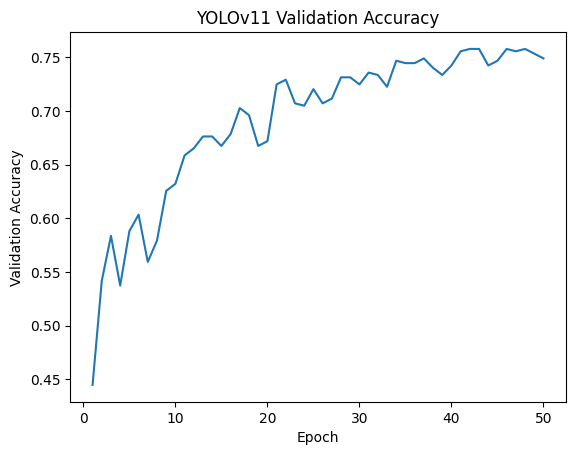

In [99]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["epoch"], df["metrics/accuracy_top1"])
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("YOLOv11 Validation Accuracy")
plt.show()


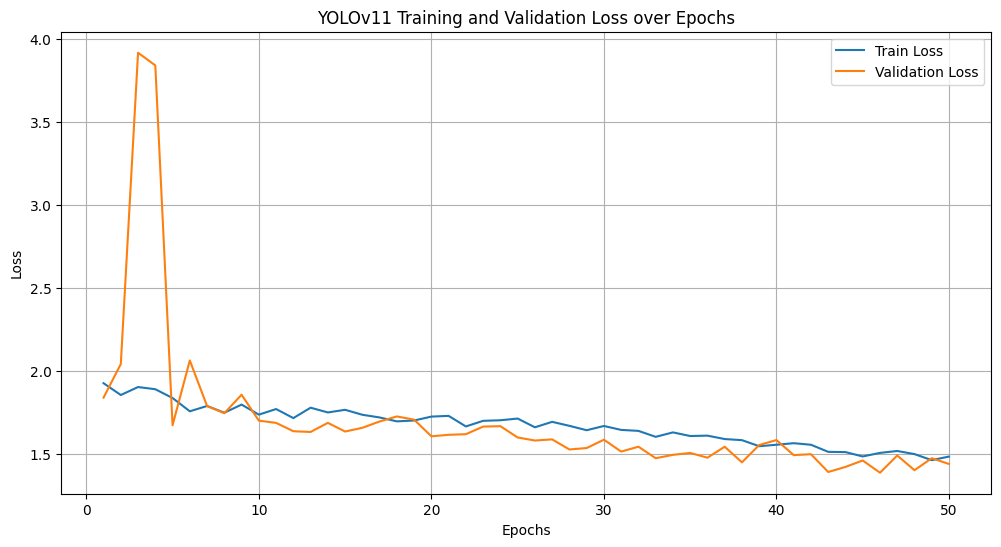

In [136]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df["epoch"], df["train/loss"], label="Train Loss")
plt.plot(df["epoch"], df["val/loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("YOLOv11 Training and Validation Loss over Epochs")
plt.legend()
plt.grid(True)
plt.show()

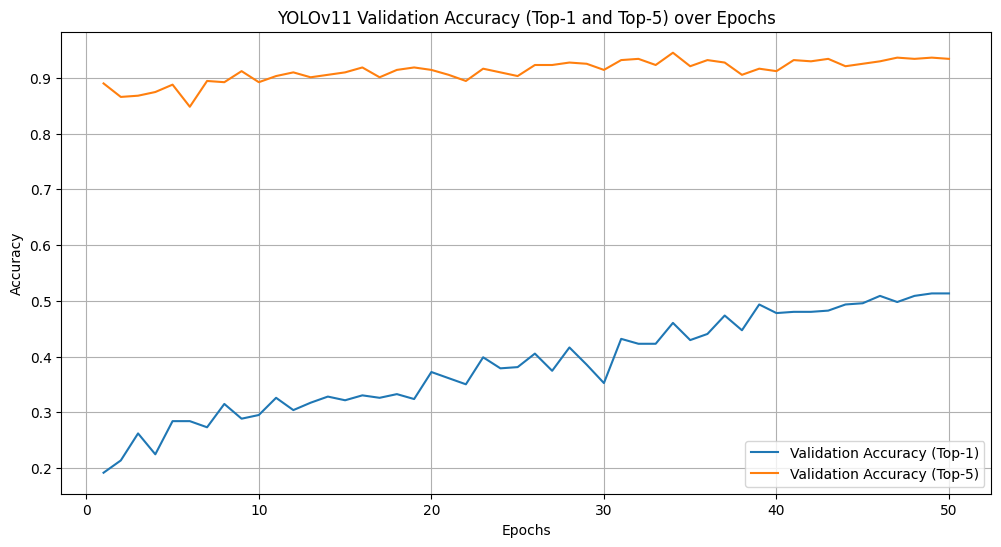

In [138]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df["epoch"], df["metrics/accuracy_top1"], label="Validation Accuracy (Top-1)")
plt.plot(df["epoch"], df["metrics/accuracy_top5"], label="Validation Accuracy (Top-5)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("YOLOv11 Validation Accuracy (Top-1 and Top-5) over Epochs")
plt.legend()
plt.grid(True)
plt.show()

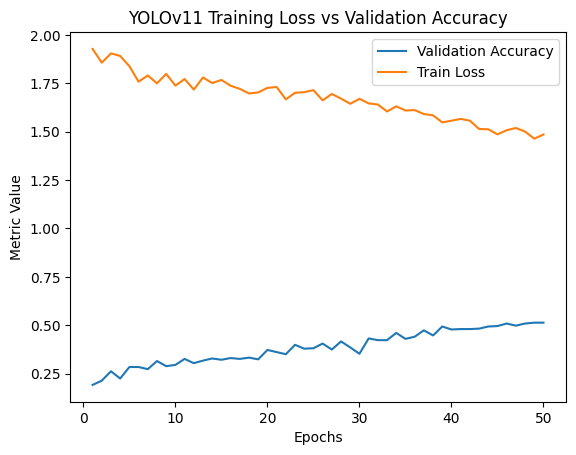

In [143]:
import matplotlib.pyplot as plt

plt.plot(df["epoch"], df["metrics/accuracy_top1"], label="Validation Accuracy")
plt.plot(df["epoch"], df["train/loss"], label="Train Loss") # Changed to train/loss
plt.xlabel("Epochs")
plt.ylabel("Metric Value") # Changed label to be more generic
plt.legend()
plt.title("YOLOv11 Training Loss vs Validation Accuracy") # Updated title
plt.show()


In [101]:
from ultralytics import YOLO
from sklearn.metrics import classification_report
import os

model = YOLO("/content/drive/MyDrive/YOLO_MMOTU_RESULTS/yolov11_cls/weights/best.pt")

y_true = []
y_pred = []

# Collect all test image paths from class subdirectories
test_image_paths = []
test_root = os.path.join(OUTPUT_ROOT, "test") # Correct path to the test data

# Assuming CLASS_MAP is available from previous cells.
# class_names_list and class_to_idx will be derived from CLASS_MAP.
class_names_list = list(CLASS_MAP.values())
class_to_idx = {name: i for i, name in enumerate(class_names_list)}

for cls_name in class_names_list: # Iterate through each class subdirectory
    cls_path = os.path.join(test_root, cls_name)
    if os.path.exists(cls_path):
        for img_file in os.listdir(cls_path):
            # Filter for common image file extensions
            if img_file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp', '.tiff', '.webp')):
                test_image_paths.append(os.path.join(cls_path, img_file))

# Perform prediction on the collected list of image paths
results = model.predict(
    source=test_image_paths,
    imgsz=224,
    save=False
)

for r in results:
    y_pred.append(r.probs.top1) # Get the top1 predicted class index
    # Extract the true class label from the image path
    # The path structure is /content/MMOTU_splits_full/test/CLASS_NAME/image.jpg
    y_true.append(os.path.basename(os.path.dirname(r.path)))

# Convert true class names to indices for classification_report
y_true_idx = [class_to_idx[c] for c in y_true]

print(classification_report(y_true_idx, y_pred, target_names=class_names_list))



0: 224x224 Normal_Ovary 1.00, Chocolate_Cyst 0.00, Simple_Cyst 0.00, Mucinous_Cystadenoma 0.00, Serous_Cystadenoma 0.00, 30.7ms
1: 224x224 Normal_Ovary 1.00, Theca_Cell_Tumor 0.00, Teratoma 0.00, Simple_Cyst 0.00, Serous_Cystadenoma 0.00, 30.7ms
2: 224x224 Normal_Ovary 0.99, Serous_Cystadenoma 0.01, Teratoma 0.00, Theca_Cell_Tumor 0.00, Chocolate_Cyst 0.00, 30.7ms
3: 224x224 Normal_Ovary 1.00, Theca_Cell_Tumor 0.00, Chocolate_Cyst 0.00, Teratoma 0.00, Simple_Cyst 0.00, 30.7ms
4: 224x224 Serous_Cystadenoma 0.76, Normal_Ovary 0.21, Chocolate_Cyst 0.03, Teratoma 0.00, Mucinous_Cystadenoma 0.00, 30.7ms
5: 224x224 Normal_Ovary 1.00, Teratoma 0.00, Theca_Cell_Tumor 0.00, Mucinous_Cystadenoma 0.00, Simple_Cyst 0.00, 30.7ms
6: 224x224 Normal_Ovary 1.00, Theca_Cell_Tumor 0.00, Simple_Cyst 0.00, Chocolate_Cyst 0.00, Mucinous_Cystadenoma 0.00, 30.7ms
7: 224x224 Normal_Ovary 1.00, Teratoma 0.00, Theca_Cell_Tumor 0.00, Mucinous_Cystadenoma 0.00, Simple_Cyst 0.00, 30.7ms
8: 224x224 Chocolate_Cyst 0

In [105]:
!find /usr/local/lib/python3.12/dist-packages/ultralytics -path "*v12*" -name "yolov12s.yaml"


In [108]:
!ls /usr/local/lib/python3.12/dist-packages/ultralytics/cfg/models


11  12	rt-detr  v10  v3  v5  v6  v8  v9


In [110]:
!ls /usr/local/lib/python3.12/dist-packages/ultralytics/cfg/models/v12

ls: cannot access '/usr/local/lib/python3.12/dist-packages/ultralytics/cfg/models/v12': No such file or directory


In [114]:
!git clone https://github.com/ultralytics/ultralytics.git


fatal: destination path 'ultralytics' already exists and is not an empty directory.


In [117]:
model = YOLO("ultralytics/ultralytics/cfg/models/12/yolo12-cls.yaml")


WARNING ⚠️ no model scale passed. Assuming scale='n'.
YOLO12-cls summary: 152 layers, 1,820,976 parameters, 1,820,976 gradients, 3.7 GFLOPs


In [120]:
yaml_content = """
# YOLO12-cls image classification model

nc: 7

scales:
  n: [0.50, 0.25, 1024]
  s: [0.50, 0.50, 1024]
  m: [0.50, 1.00, 512]
  l: [1.00, 1.00, 512]
  x: [1.00, 1.50, 512]

backbone:
  - [-1, 1, Conv, [64, 3, 2]]
  - [-1, 1, Conv, [128, 3, 2]]
  - [-1, 2, C3k2, [256, False, 0.25]]
  - [-1, 1, Conv, [256, 3, 2]]
  - [-1, 2, C3k2, [512, False, 0.25]]
  - [-1, 1, Conv, [512, 3, 2]]
  - [-1, 4, A2C2f, [512, True, 4]]
  - [-1, 1, Conv, [1024, 3, 2]]
  - [-1, 4, A2C2f, [1024, True, 1]]

head:
  - [-1, 1, Classify, [nc]]
"""

with open("/content/yolo12-cls-mmoutu.yaml", "w") as f:
    f.write(yaml_content)

print("YAML file created successfully")


YAML file created successfully


In [121]:
import os
print(os.path.exists("/content/yolo12-cls-mmoutu.yaml"))


True


In [122]:
from ultralytics import YOLO

model = YOLO("/content/yolo12-cls-mmoutu.yaml")


WARNING ⚠️ no model scale passed. Assuming scale='n'.
YOLO12-cls-mmoutu summary: 152 layers, 1,727,463 parameters, 1,727,463 gradients, 3.6 GFLOPs


In [124]:
from ultralytics import YOLO

DATA_PATH = "/content/drive/MyDrive/MMOTU_splits_full"

# Load YOLOv12 classification model (YAML, no pretrained .pt exists yet)
model_v12 = YOLO("/content/yolo12-cls-mmoutu.yaml")

model_v12.train(
    data=DATA_PATH,
    epochs=50,              # SAME as YOLOv8 & YOLOv11
    imgsz=224,              # Classification standard
    batch=32,

    project="/content/drive/MyDrive/YOLO_MMOTU_RESULTS",
    name="yolov12_cls",

    # SAME augmentation as YOLOv11 (fair comparison)
    fliplr=0.5,
    flipud=0.3,
    degrees=10,
    translate=0.1,
    scale=0.5,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4
)


WARNING ⚠️ no model scale passed. Assuming scale='n'.
YOLO12-cls-mmoutu summary: 152 layers, 1,727,463 parameters, 1,727,463 gradients, 3.6 GFLOPs
Ultralytics 8.3.240 🚀 Python-3.12.12 torch-2.9.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MMOTU_splits_full, degrees=10, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.3, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/yolo12-cls-mmoutu.yaml, momentum=0.

ultralytics.utils.metrics.ClassifyMetrics object with attributes:

confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ec3babb78c0>
curves: []
curves_results: []
fitness: 0.7235682606697083
keys: ['metrics/accuracy_top1', 'metrics/accuracy_top5']
results_dict: {'metrics/accuracy_top1': 0.5132158398628235, 'metrics/accuracy_top5': 0.933920681476593, 'fitness': 0.7235682606697083}
save_dir: PosixPath('/content/drive/MyDrive/YOLO_MMOTU_RESULTS/yolov12_cls')
speed: {'preprocess': 0.0006485660887366398, 'inference': 20.061874947153463, 'loss': 3.434360972995406e-05, 'postprocess': 8.425993230993888e-05}
task: 'classify'
top1: 0.5132158398628235
top5: 0.933920681476593

In [125]:
project="/content/drive/MyDrive/YOLO_MMOTU_RESULTS"
name="yolov12_cls"


In [126]:
import pandas as pd

csv_path = "/content/drive/MyDrive/YOLO_MMOTU_RESULTS/yolov12_cls/results.csv"
df = pd.read_csv(csv_path)

# Show last epoch (final performance)
df.tail(1)


,epoch,time,train/loss,metrics/accuracy_top1,metrics/accuracy_top5,val/loss,lr/pg0,lr/pg1,lr/pg2
49,50,5643.21,1.48538,0.51322,0.93392,1.44068,0.000027,0.000027,0.000027


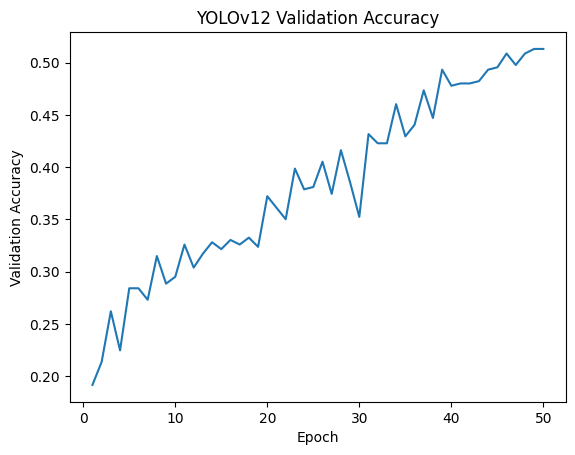

In [129]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(df["epoch"], df["metrics/accuracy_top1"])
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("YOLOv12 Validation Accuracy")
plt.show()


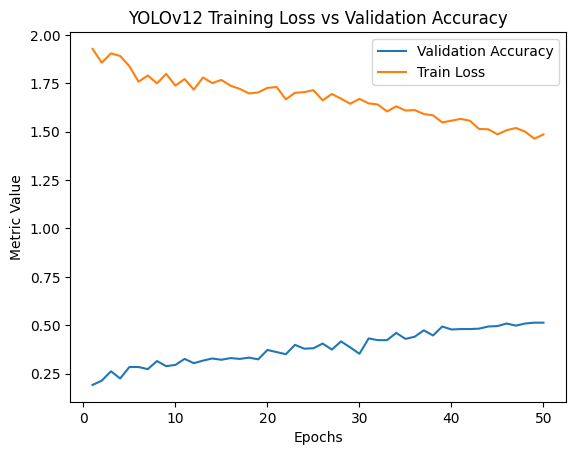

In [133]:
import matplotlib.pyplot as plt

plt.plot(df["epoch"], df["metrics/accuracy_top1"], label="Validation Accuracy")
plt.plot(df["epoch"], df["train/loss"], label="Train Loss") # Changed to train/loss
plt.xlabel("Epochs")
plt.ylabel("Metric Value") # Changed label to be more generic
plt.legend()
plt.title("YOLOv12 Training Loss vs Validation Accuracy") # Updated title
plt.show()


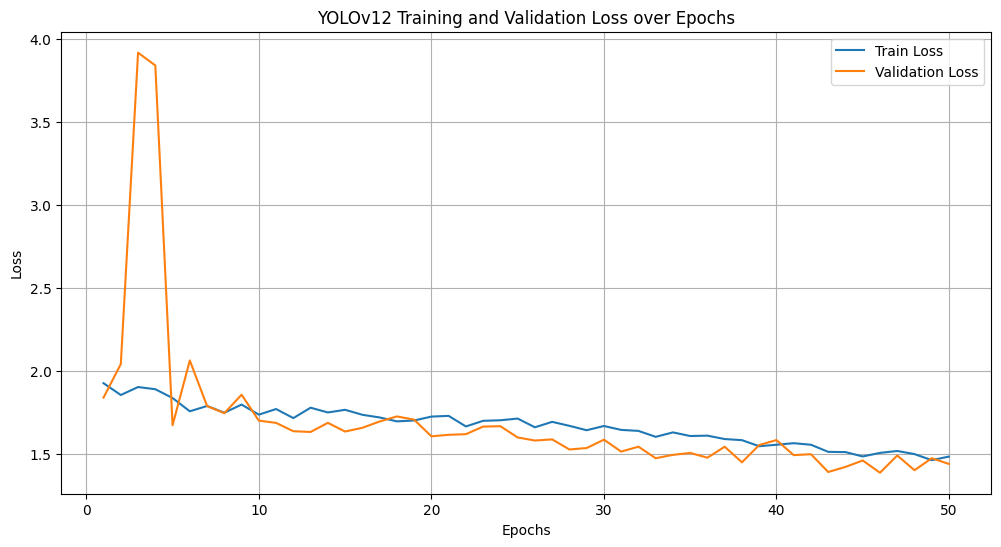

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df["epoch"], df["train/loss"], label="Train Loss")
plt.plot(df["epoch"], df["val/loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("YOLOv12 Training and Validation Loss over Epochs")
plt.legend()
plt.grid(True)
plt.show()

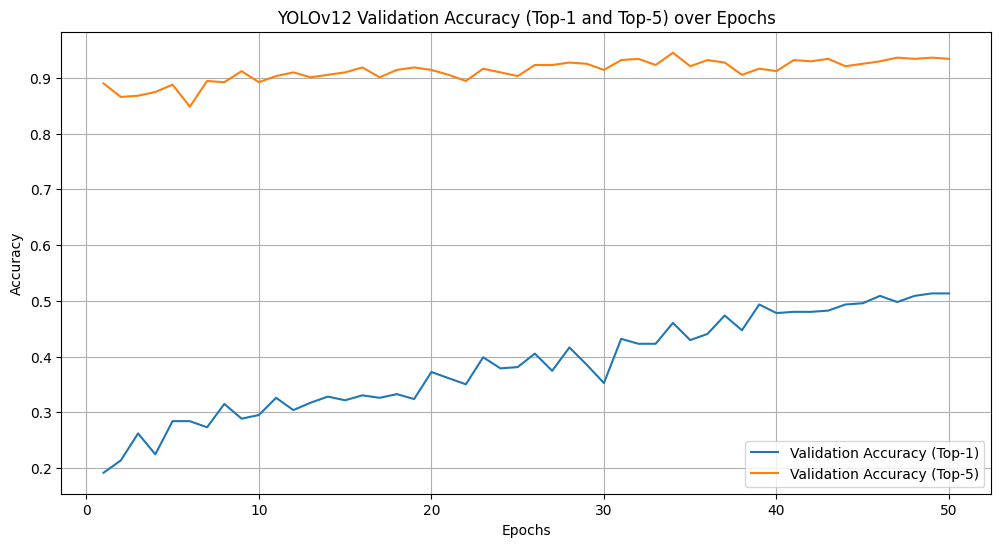

In [135]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df["epoch"], df["metrics/accuracy_top1"], label="Validation Accuracy (Top-1)")
plt.plot(df["epoch"], df["metrics/accuracy_top5"], label="Validation Accuracy (Top-5)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("YOLOv12 Validation Accuracy (Top-1 and Top-5) over Epochs")
plt.legend()
plt.grid(True)
plt.show()